In [1]:
#这里用的是李沐教学时的小数据集，通过URL下载
%matplotlib inline
import os
import pandas as pd
import torch
import torchvision
from d2l import torch as d2l

In [2]:
d2l.DATA_HUB['banana-detection'] = (
    d2l.DATA_URL + 'banana-detection.zip',
    '5de26c8fce5ccdea9f91267273464dc968d20d72')

In [3]:
# #读取香蕉检测数据集
"""读取香蕉检测数据集中的图像和标签"""
def read_data_bananas(is_train=True):
    data_dir=d2l.download_extract('banana-detection')
    csv_fname=os.path.join(data_dir,
                        'bananas_train' if is_train else 'bananas_val','label.csv')
    csv_data=pd.read_csv(csv_fname)
    csv_data=csv_data.set_index('img_name')
    images,targets=[],[]
    for img_name,target in csv_data.iterrows():
        images.append(
            torchvision.io.read_image(
                os.path.join(data_dir,'bananas_train' if is_train else 'bananas_val','images',f'{img_name}')))
        targets.append(list(target))
    return images,torch.tensor(targets).unsqueeze(1)/256

In [4]:
#创建一个自定义Dataset实例
class BananaDataset(torch.utils.data.Dataset):
    """一个用于加载香蕉检测数据集的自定义数据集"""
    def __init__(self,is_train):
        self.features,self.labels=read_data_bananas(is_train)
        print('read' + str(len(self.features))+(f'training examples' if is_train else f'validation examples'))
    
    def __getitem__(self, index):
        return (self.features[index].float(),self.labels[index])
    
    def __len__(self):
        return len(self.features)

In [5]:
def load_data_banana(batch_size):
    """加载香蕉检测数据集"""
    train_iter=torch.utils.data.DataLoader(BananaDataset(is_train=True),batch_size,shuffle=True)
    val_iter=torch.utils.data.DataLoader(BananaDataset(is_train=False),batch_size,shuffle=False)
    return train_iter,val_iter

In [6]:
#读取小批量，并打印图像和标签形状
batch_size,edge_size=32,256
train_iter,_=load_data_banana(batch_size)
batch=next(iter(train_iter))
batch[0].shape,batch[1].shape#batch[1].shape输出[32,1,5]，其中1表示图片中最多识别1个物体，5表示标号加上左上和右下的4个数值

read1000training examples
read100validation examples


(torch.Size([32, 3, 256, 256]), torch.Size([32, 1, 5]))

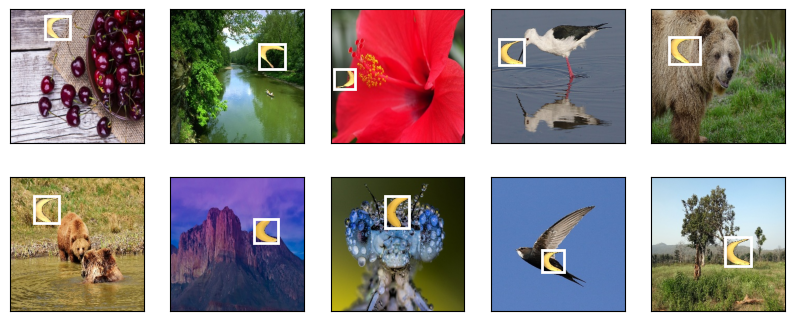

In [10]:
imgs=(batch[0][0:10].permute(0,2,3,1))/255
axes=d2l.show_images(imgs,2,5,scale=2)
for ax,label in zip(axes,batch[1][0:10]):
    d2l.show_bboxes(ax,[label[0][1:5]*edge_size],colors=['w'])